#### Imports

In [1]:
import numpy as np
import numba as nb
from numba.typed import List
import math
from time import perf_counter
import matplotlib.pyplot as plt

#### Function definitions

In [ ]:
LOG2 = math.log(2.0)


@nb.njit(fastmath=False, cache=True)
def get_grid(t):
    """
    Compute the grid Gt for a given time step t. Non-recursive version.

    Parameters
    ----------
    t : int

    Returns
    -------
    np.ndarray (int64)
        The grid Gt as an integer NumPy array.
    """
    # Handle edge case t <= 1 (consistent with the commented R behavior for t==1)
    if t <= 1:
        out = np.empty(1, dtype=np.int64)
        out[0] = 1
        return out

    # Compute upper bounds using base-2 logs via math.log(...)
    # upper1 <- floor(log((t - 1) / 3, base = 2)) + 1
    # upper2 <- floor(log(t - 1, base = 2)) - 1
    upper1 = math.floor(math.log((t - 1) / 3.0) / LOG2) + 1
    upper2 = math.floor(math.log(t - 1) / LOG2) - 1

    # Preallocate output array
    length = 1 + (upper1 if upper1 > 0 else 0) + (upper2 if upper2 > 0 else 0)
    Gt = np.empty(length, dtype=np.int64)

    # Gt[1] <- 1  (R is 1-based; Python is 0-based)
    Gt[0] = 1
    counter = 1

    if upper1 >= 1:
        for j in range(1, upper1 + 1):
            # gL <- 2^j + (t - 1) %% 2^(j - 1)
            gL = (1 << j) + ((t - 1) % (1 << (j - 1)))
            Gt[counter] = gL
            counter += 1

            if j <= upper2:
                # Gt[counter] <- gL + 2^(j - 1)
                Gt[counter] = gL + (1 << (j - 1))
                counter += 1

    return Gt


@nb.njit(fastmath=False, cache=True)
def v2_numba(r: int) -> int:
    """
    Compute the exponent of the largest power of 2 that divides r.
    """
    if r == 0:
        return -1
    if r < 0:
        r = -r
    c = 0
    while (r & 1) == 0:
        c += 1
        r >>= 1
    return c


@nb.njit(fastmath=False, cache=True)
def log2_floor(x: int) -> float:
    if x <= 0:
        raise ValueError("x must be positive")
    n = 0
    v = x  # assume x is int64 and positive
    if v >= (1 << 32):
        v >>= 32
        n += 32
    if v >= (1 << 16):
        v >>= 16
        n += 16
    if v >= (1 << 8):
        v >>= 8
        n += 8
    if v >= (1 << 4):
        v >>= 4
        n += 4
    if v >= (1 << 2):
        v >>= 2
        n += 2
    if v >= (1 << 1):
        n += 1
    return n * 1.0


@nb.njit(fastmath=True, cache=True)
def fastlog(x):
    return math.log(x)


@nb.njit(fastmath=False, cache=True)
def update_grid(old_grid, t):
    """
    Update the grid old_grid in place to reflect the addition of a new data point at time t.
    Parameters
    ----------
    old_grid : List[int]
        The current grid to be updated.
    t : int
        The current (i.e., new) time step.
    """
    removed = -1
    removed_g = -1

    if t == 2 or t == 3:
        removed_g = old_grid[0]
        old_grid.pop(0)
        removed = 0
    elif t > 3:
        j = v2_numba(t - 1) + 1
        if j > 0:
            ind = 2 * j

            if ind < len(old_grid):
                removed = len(old_grid) - ind - 1
                removed_g = old_grid[removed]
                old_grid.pop(removed)

    old_grid.append(-t)

    return removed, removed_g


@nb.njit(fastmath=False, cache=True)
def update_data_grid(x_new, old_sums, old_S, t, removed):
    if removed >= 0:
        old_sums.pop(removed)
    old_sums.append(old_S)
    S = old_S + x_new
    return S


@nb.njit(fastmath=False, cache=True)
def CUSUM(S, cumsum, g, t):
    res = math.sqrt(1.0 * g / (t * (t - g))) * cumsum
    res = res - math.sqrt(1.0 * (t - g) / t / g) * (S - cumsum)
    return res * res


@nb.njit(fastmath=False, cache=True, inline="always")
def CUSUM2(S, cumsum, g, t):
    return (t * cumsum - (t - g) * S) ** 2 / (g * t * (t - g))


@nb.njit("f8(f8, f8, f8, f8)", fastmath=False, cache=True, inline="always")
def CUSUM3(S, cumsum, g, t):
    dt = t - g
    num = t * cumsum - dt * S
    denom = g * t * dt

    return (num * num) / denom


@nb.njit(fastmath=True, cache=True)
def update_full(x_new, sums, lam, t, delta, s_size):
    alarm = False
    maxx = 0.0
    maxpos = -1
    logg = fastlog(t / delta)
    logg = logg + math.sqrt(logg)
    new_s_size = s_size
    sums_new = None

    if t > s_size:
        new_s_size = 2 * new_s_size
        sums_new = np.zeros(new_s_size, dtype=np.float64)
        for i in range(t - 1):
            sums_new[i] = sums[i]
        sums_new[t - 1] = sums[-1] + x_new
    else:
        sums_new = sums
        sums_new[t - 1] = sums[t - 2] + x_new

    if t > 1:
        for j in range(t - 1):
            g = t - j - 1
            cc = (CUSUM3(sums_new[t - 1], sums_new[j], g, t) - 1) / logg
            if cc > maxx:
                maxx = cc
                maxpos = j + 1
            if cc > lam:
                alarm = True

    return alarm, maxx, maxpos, sums_new, new_s_size


@nb.njit(fastmath=False, cache=True)
def update_grid_method(x_new, sums, S, lam, t, delta, grid):
    removed, removed_g = update_grid(grid, t)
    S_new = update_data_grid(x_new, sums, S, t, removed)
    alarm = False
    maxx = 0.0
    maxpos = -1
    logg = fastlog(t / delta)
    logg = logg + math.sqrt(logg)
    if t > 1:
        for j in range(len(grid) - 1, -1, -1):
            g = grid[j] + t + 1
            cc = (CUSUM3(S_new, sums[j], g, t) - 1) / logg
            if cc > maxx:
                maxx = cc
                maxpos = grid[j] + t + 1
            if cc > lam:
                alarm = True

    return alarm, maxx, maxpos, sums, S_new, grid


@nb.njit(fastmath=False, cache=True)
def static_cusum(x, grid):
    ccs = []
    n = len(x)
    for j in range(len(grid)):
        i = grid[j]
        g = i + 1

        cc = (
            np.sum(x[: (n - g)]) * math.sqrt(1.0 * g / (n * (n - g)))
            - np.sum(x[(n - g) :]) * math.sqrt(1.0 * (n - g) / n / g)
        ) ** 2
        ccs.append(cc)
    return ccs


@nb.njit(fastmath=False, cache=True)
def train_full(N, K, seed, delta):
    np.random.seed(seed)
    vals = np.zeros(K)
    for k in range(K):
        lam = 0.0
        t = 1

        s_size = 64
        sums = np.zeros(s_size, np.float64)
        x = np.random.normal(0, 1, N)
        val = 0.0
        for i in range(N):
            t = i + 1
            alarm, maxx, maxpos, sums_new, new_s_size = update_full(
                x[i], sums, lam, t, delta, s_size
            )
            s_size = new_s_size
            sums = sums_new
            if maxx > val:
                val = maxx
        vals[k] = val

    return vals


@nb.njit(fastmath=False, cache=True)
def train_grid(N, K, seed, delta):
    np.random.seed(seed)
    vals = np.zeros(K)
    for k in range(K):
        S = 0.0
        lam = 0.0
        t = 1
        grid = List([0])
        grid.pop()

        sums = List([0.0])
        sums.pop()
        x = np.random.normal(0, 1, N)
        val = 0.0
        for i in range(N):
            t = i + 1
            alarm, maxx, maxpos, sums, S, grid = update_grid_method(
                x[i], sums, S, lam, t, delta, grid
            )
            if maxx > val:
                val = maxx
        vals[k] = val

    return vals


@nb.njit(fastmath=False, cache=True)
def run_simulation(
    sim, N, change_lower, change_upper, mu, lam_grid, lam_full, seed, delta
):

    alarms_grid = np.ones(sim, dtype=np.int64) * N
    alarms_full = np.ones(sim, dtype=np.int64) * N
    changelocs = np.zeros(sim, dtype=np.int64)

    np.random.seed(seed)
    for k in range(sim):
        x = np.random.normal(0, 1, N)
        changeloc = np.random.randint(change_lower, change_upper)
        changelocs[k] = changeloc
        x[changeloc:] += mu  # Introduce a change point

        S = 0.0
        t = 1
        grid = List([0])
        grid.pop()

        sums = List([0.0])
        sums.pop()

        cusums = List([0.0])
        cusums.pop()

        s_size = 64
        sums_full = np.zeros(s_size, np.float64)

        for i in range(N):
            t = i + 1
            if alarms_grid[k] == N:
                alarm, maxx, maxpos, sums, S, grid = update_grid_method(
                    x[i], sums, S, lam_grid, t, delta, grid
                )
                if alarm:
                    if alarms_grid[k] == N:
                        alarms_grid[k] = t

            if alarms_full[k] == N:
                alarm_full, maxx_full, maxpos_full, sums_new_full, new_s_size = (
                    update_full(x[i], sums_full, lam_full, t, delta, s_size)
                )
                sums_full = sums_new_full
                s_size = new_s_size

                if alarm_full:
                    if alarms_full[k] == N:
                        alarms_full[k] = t

    return alarms_grid, alarms_full, changelocs

#### Test run!!

In [ ]:
np.random.seed(42)
N = 502
x = np.random.rand(N)
x[500:] += 3.0  # Introduce a change point


delta = 0.05
S = 0.0
lam = 1
lam_full = 2.0
t = 1
grid = List([0])
grid.pop()

sums = List([0.0])
sums.pop()


s_size = 32
sums_full = np.zeros(s_size, dtype=np.float64)


for i in range(N):
    t = i + 1
    alarm, maxx, maxpos, sums, S, grid = update_grid_method(
        x[i], sums, S, lam, t, delta, grid
    )
    if alarm:
        print(
            "Grid-based alarm at time ",
            t,
            " at position ",
            maxpos,
            " with value ",
            maxx,
        )

    alarm_full, maxx_full, maxpos_full, sums_full, s_size = update_full(
        x[i], sums_full, lam_full, t, delta, s_size
    )
    if alarm_full:
        print(
            "Full scan alarm at time ",
            t,
            " at position ",
            maxpos_full,
            " with value ",
            maxx_full,
        )

Standard alarm at time  502  at position  2  with value  1.4998909553999014


#### Simulation study

In [ ]:
N = 20_000
K = 10_000
delta = 0.05
seed = 123412

# pre-compile the functions by running a single simulation
_ = train_grid(1000, 1, seed, delta)
_ = train_full(1000, 1, seed, delta)

In [ ]:
t0 = perf_counter()
sample_grid = train_grid(N, K, seed, delta)
t_grid = perf_counter() - t0
print(f"Grid training time for N={N}, K={K}: {t_grid:.4f} seconds")

Grid training time for N=20000, K=10000: 155.4960 seconds


In [ ]:
t0 = perf_counter()
sample_full = train_full(N, K, seed, delta)
t_full = perf_counter() - t0
print(f"Full training time for N={N}, K={K}: {t_full:.4f} seconds")

Full training time for N=20000, K=10000: 2599.6479 seconds


In [35]:
lam_grid = np.quantile(sample_grid, 1 - delta)
lam_full = np.quantile(sample_full, 1 - delta)
print(lam_grid)
print(lam_full)

1.7358545548125581
1.8093167474664305


In [ ]:
# lam_grid = 1.7358545548125581
# lam_full = 1.8093167474664305

In [7]:
change_lower = N // 4
change_upper = N // 2
mu = 1000
seed = 12345
sim = 40


alarms_grid, alarms_full, changeloc = run_simulation(
    sim, N, change_lower, change_upper, mu, lam_grid, lam_full, seed, delta
)

In [8]:
changeloc

array([7936, 6715, 9937, 6806, 7094, 8631, 6051, 6174, 9464, 5775, 9355,
       8648, 6243, 5287, 8578, 5365, 7541, 5932, 5613, 8585, 8969, 9893,
       7474, 8383, 7106, 8972, 5079, 7175, 7946, 9882, 9738, 7281, 5778,
       7122, 6372, 9463, 7492, 7044, 9433, 7733])

In [ ]:
sim = 1000

change_lower = N // 4
change_upper = N // 2

mus = np.arange(0.0, 0.2, 0.01)
mus = np.concatenate(
    [mus, np.arange(0.2, 0.6, 0.05), np.arange(0.6, 2, 0.2), np.arange(2.5, 3.6, 0.5)]
)
seed = 12345

dds_grid = np.zeros(len(mus))
dds_full = np.zeros(len(mus))

for i in range(len(mus)):
    if i % 5 == 0:
        print("mu =", mus[i])
    alarms_grid, alarms_full, changeloc = run_simulation(
        sim,
        N,
        change_lower,
        change_upper,
        mus[i],
        lam_grid,
        lam_full,
        seed,
        delta,
    )
    dds_grid[i] = np.mean(
        alarms_grid[alarms_grid >= changeloc] - changeloc[alarms_grid >= changeloc]
    )
    dds_full[i] = np.mean(
        alarms_full[alarms_full >= changeloc] - changeloc[alarms_full >= changeloc]
    )

mu = 0.0
mu = 0.05
mu = 0.1
mu = 0.15
mu = 0.2
mu = 0.44999999999999996
mu = 1.0
mu = 2.5


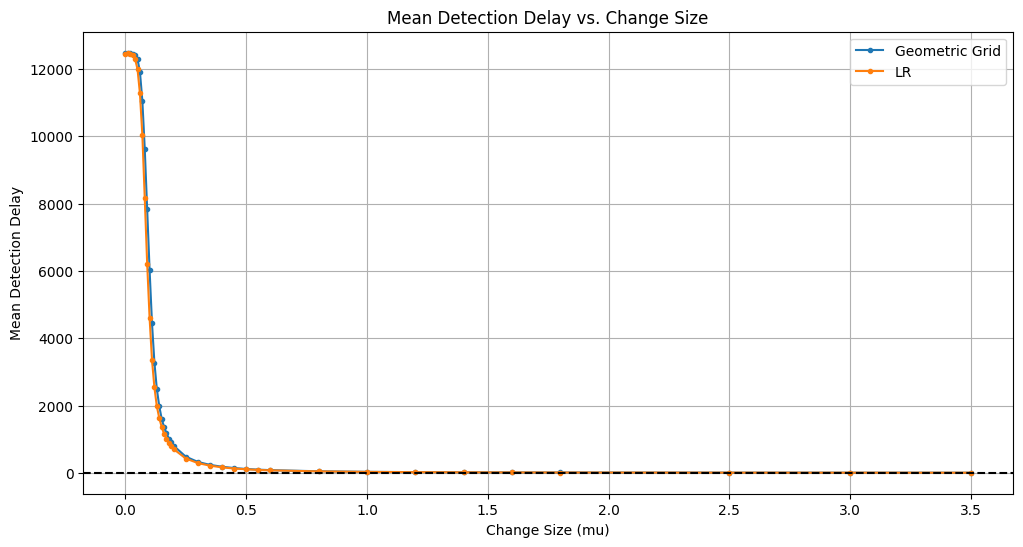

In [21]:
# plot the results
plt.figure(figsize=(12, 6))
plt.plot(mus, dds_grid, label="Geometric Grid", marker="o", markersize=3)
plt.plot(mus, dds_full, label="LR", marker="o", markersize=3)
plt.axhline(y=0, color="k", linestyle="--")
plt.title("Mean Detection Delay vs. Change Size")
plt.xlabel("Change Size (mu)")
plt.ylabel("Mean Detection Delay")
plt.legend()
plt.grid()
plt.savefig("dd_vs_change_size_full_vs_grid.pdf")
plt.show()

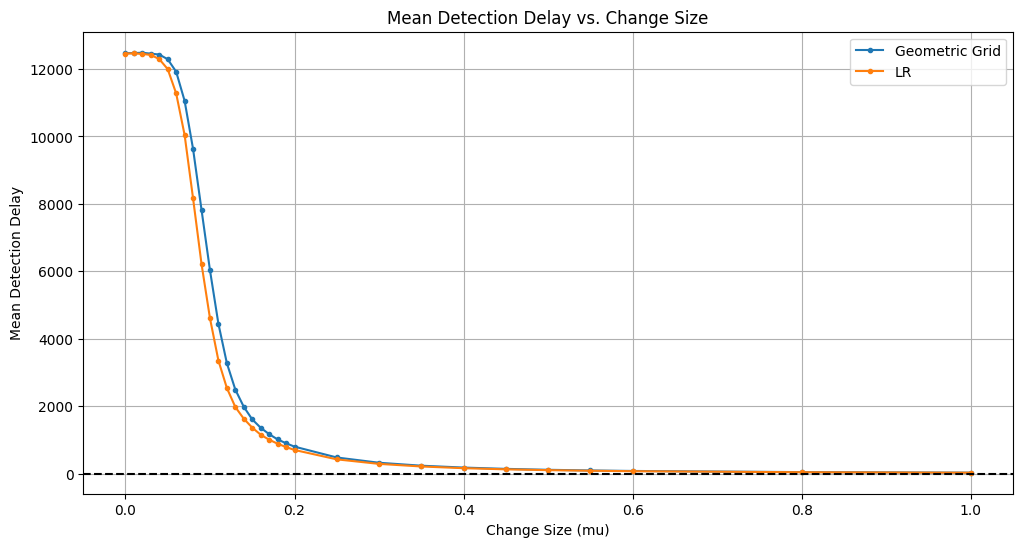

In [22]:
# plot the results
plt.figure(figsize=(12, 6))
plt.plot(
    mus[mus <= 1], dds_grid[mus <= 1], label="Geometric Grid", marker="o", markersize=3
)

plt.plot(mus[mus <= 1], dds_full[mus <= 1], label="LR", marker="o", markersize=3)


plt.axhline(y=0, color="k", linestyle="--")
plt.title("Mean Detection Delay vs. Change Size")
plt.xlabel("Change Size (mu)")
plt.ylabel("Mean Detection Delay")
plt.legend()
plt.grid()
plt.savefig("dd_vs_change_size_full_vs_grid_zoomed.pdf")
plt.show()

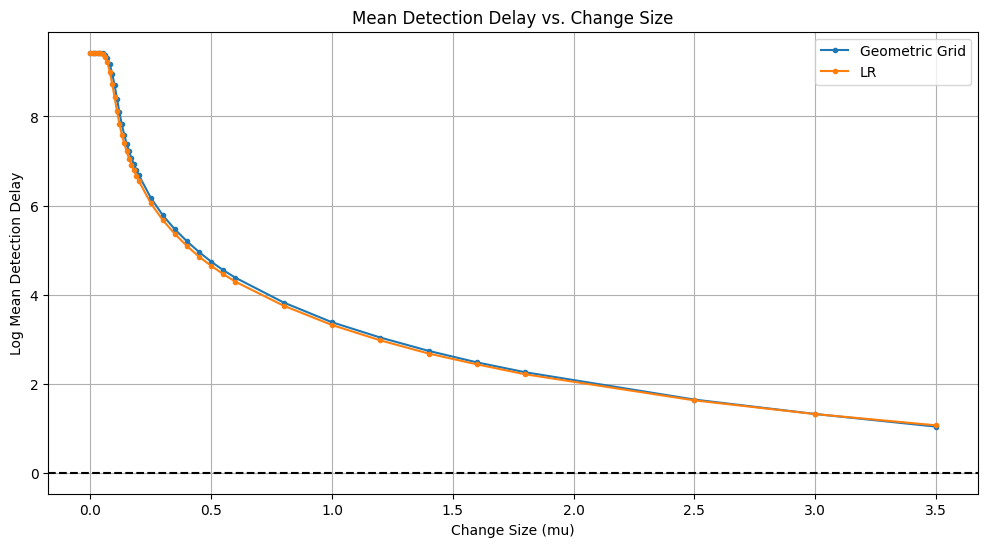

In [23]:
# plot the results
plt.figure(figsize=(12, 6))
plt.plot(mus, np.log(dds_grid), label="Geometric Grid", marker="o", markersize=3)
plt.plot(mus, np.log(dds_full), label="LR", marker="o", markersize=3)
plt.axhline(y=0, color="k", linestyle="--")
plt.title("Mean Detection Delay vs. Change Size")
plt.xlabel("Change Size (mu)")
plt.ylabel("Log Mean Detection Delay")
plt.legend()
plt.grid()
plt.savefig("dd_vs_change_size_full_vs_grid_log.pdf")
plt.show()